## PHASE 1 — Load Data and Understand Its Structure

##### 0.1 The task is regression
##### 0.2 so, gonna use "RMSE/MAE" Evaulation matrix

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [4]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [5]:
# Dimension of the dataset
df.shape

(77299, 11)

In [6]:
df['Index'].nunique()

77299

##### 0.3 All the rows are unique and independent. Therefor, will use Stratified K-Fold

In [7]:
# 1.2: Type of column
## for each column, will be checking its dtype, no. of unique values.

def ColumnAnalysis(dataframe):

    columns = dataframe.columns

    for col in columns:

        bold_col = f"\033[1m{col}\033[0m"  #creating helper variable!

        print(f"Data type of {bold_col} column: {dataframe[col].dtype}")
        print(f"Unique values in '{bold_col}' column: {dataframe[col].nunique()}")

        if dataframe[col].value_counts().shape[0] < 25:
            counts = dataframe[col].value_counts()
            summary = pd.DataFrame({
                'Value' : counts,
                'Percentage (%)' :  (counts/len(dataframe)*100).round(2)
            })
            print(summary)

        else:
            print(f"Count of unique values in {bold_col} column is more than 25, so not displaying the count.")
        print(f"sample values in {bold_col} column: \n{dataframe[col].sample(10)}")

        print('\n')
        print("="*90)


In [8]:
ColumnAnalysis(df)

Data type of Index column: int64
Unique values in 'Index' column: 77299
Count of unique values in Index column is more than 25, so not displaying the count.
sample values in Index column: 
4924      4924
3797      3797
14777    14777
10364    10364
11876    11876
42698    42698
60736    60736
70292    70292
34597    34597
66218    66218
Name: Index, dtype: int64


Data type of geohash column: str
Unique values in 'geohash' column: 1249
Count of unique values in geohash column is more than 25, so not displaying the count.
sample values in geohash column: 
37936    qp0979
24167    qp09bk
27869    qp06ne
17614    qp03wt
50386    qp09ut
60638    qp09de
74932    qp096n
8397     qp096x
63689    qp03x9
52215    qp092n
Name: geohash, dtype: str


Data type of day column: int64
Unique values in 'day' column: 2
     Value  Percentage (%)
day                       
48   69427           89.82
49    7872           10.18
sample values in day column: 
64710    48
74722    49
74099    49
3185     48
4

In [9]:
# 1.2: Type of column- Observation
# Index: drop
# geohash: str -> as it for now
# day: int -> categorical -> 2 [48, 49]; impalance in the dataset
# timestamp: str which is 'timesseries' -> convert to datetime
# RoadType: str -> categorical(normal) -> 3 [Residential, Street, Highway]; imbalance 
# NumberofLanes: int -> categorical(Disguise) -> 5 [1,2,3,4,5] ; imbalance (1-3: high, 4-5: low)
# LargeVehicle: str -> Binary -> [Allowed, Not Allowed] ; imbalance (67:33)
# Landmarks: str -> Binary -> [Yes, No] ; imbalance (67:33)
# Tempreature: float -> no changes
# Weather: str -> categorical(normal) -> 4 [Sunny, Rainy, Foggy, Snowy] ; imbalance(Snowy)




In [10]:
# Handeling Missing Values

def NullAnalysis(dataframe):

    null_percentages = (dataframe.isnull().sum() / len(dataframe)) * 100

    null_percentages = null_percentages[
        null_percentages > 0
    ].sort_values(ascending=False)

    for col, pct in null_percentages.items():
        print(f"{col}: {pct:.2f}%")

NullAnalysis(df)

Temperature: 3.23%
Weather: 1.03%
RoadType: 0.78%


In [11]:
df['Temperature']=df['Temperature'].fillna(df['Temperature'].median(), inplace = True)
df['Weather']=df['Weather'].fillna(df['Weather'].mode()[0], inplace = True)
df['RoadType']=df['RoadType'].fillna(df['RoadType'].mode()[0], inplace = True)


/tmp/ipykernel_145027/131077036.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Temperature']=df['Temperature'].fillna(df['Temperature'].median(), inplace = True)
/tmp/ipykernel_145027/131077036.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace me

In [12]:
# Checking for dublicate values
df.duplicated().sum()

np.int64(0)

In [13]:
# convert string to datetime-like object
df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    format='%H:%M'
)

# extract components
df['hour'] = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute

df.drop(columns=["timestamp"], inplace=True)

In [14]:
df.head()

,Index,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute
0,0,qp02z1,48,0.048804,Residential,1,Not Allowed,No,16.382587,Sunny,0,0
1,1,qp02zt,48,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,0
2,2,qp08bj,48,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,0
3,3,qp08gt,48,0.003272,Residential,1,Not Allowed,No,16.382587,Rainy,0,0
4,4,qp02zq,48,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,0


In [15]:
# as correlation only capture linear relation. therefore, using groupby to analyse peak trafic time
df.groupby("hour")["demand"].mean().sort_values(ascending=False)



hour
11    0.117301
13    0.116308
12    0.114770
10    0.111602
9     0.109231
14    0.107166
7     0.106198
8     0.106149
5     0.104368
6     0.103913
4     0.101678
23    0.092517
3     0.091329
1     0.089793
2     0.087368
0     0.083369
15    0.083161
22    0.074544
16    0.070065
17    0.058905
21    0.056955
18    0.048787
20    0.043778
19    0.042114
Name: demand, dtype: float64

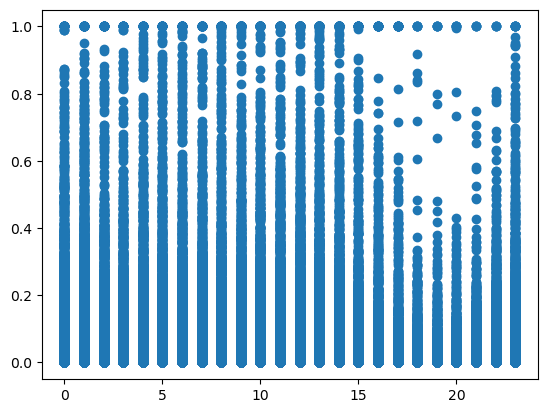

In [16]:
import matplotlib.pyplot as plt

plt.scatter(df['hour'], df['demand'], s=None, c=None, marker=None, alpha=None, linewidths=None, edgecolors=None)


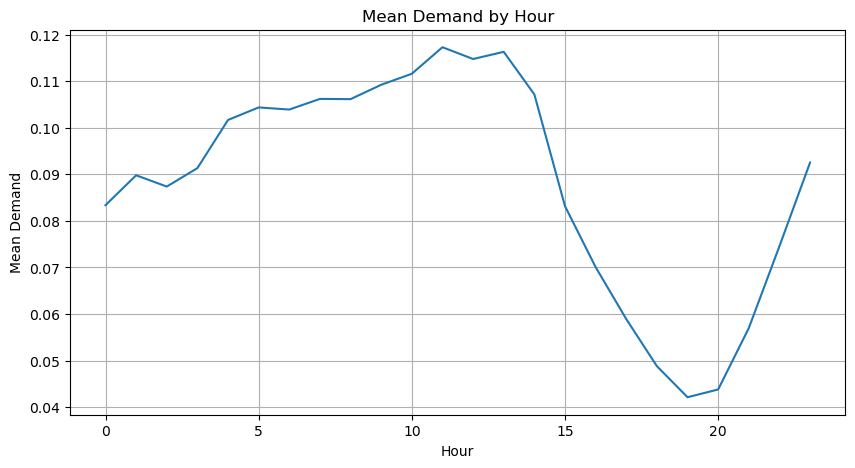

In [17]:
hourly_demand = df.groupby("hour")["demand"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_demand.index, hourly_demand.values)
plt.xlabel("Hour")
plt.ylabel("Mean Demand")
plt.title("Mean Demand by Hour")
plt.grid(True)
plt.show()

In [18]:
df.groupby("minute")["demand"].mean()


minute
0     0.093652
15    0.094172
30    0.093889
45    0.094070
Name: demand, dtype: float64

minutes variance is near 0; meaning doen't carry high predictive value

In [19]:
# Checking relation between Categorical and target varibale before encoding

def categorical_target_analysis(listofcols,target_col,dataframe):

    for col in listofcols:

        print(f"Mean relationship between {col} and {target_col}:\n")
        mean = dataframe.groupby(col)[target_col].mean().sort_values(ascending = False)
        print(mean)
        print(f"\nMedian relationship between {col} and {target_col}:\n")
        median = dataframe.groupby(col)[target_col].median().sort_values(ascending = False)
        print(median)  
        print("="*90)
        print("\n")


categorical_cols = [
    "Weather",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "NumberofLanes",
    "day"
]
categorical_target_analysis(categorical_cols,'demand',df)

Mean relationship between Weather and demand:

Weather
Rainy    0.094471
Sunny    0.094330
Foggy    0.093372
Snowy    0.092581
Name: demand, dtype: float64

Median relationship between Weather and demand:

Weather
Rainy    0.048467
Snowy    0.047775
Foggy    0.047571
Sunny    0.047353
Name: demand, dtype: float64


Mean relationship between RoadType and demand:

RoadType
Highway        0.610756
Street         0.273164
Residential    0.057562
Name: demand, dtype: float64

Median relationship between RoadType and demand:

RoadType
Highway        0.526432
Street         0.268124
Residential    0.040574
Name: demand, dtype: float64


Mean relationship between LargeVehicles and demand:

LargeVehicles
Allowed        0.131923
Not Allowed    0.073986
Name: demand, dtype: float64

Median relationship between LargeVehicles and demand:

LargeVehicles
Allowed        0.051223
Not Allowed    0.046023
Name: demand, dtype: float64


Mean relationship between Landmarks and demand:

Landmarks
No     0.0

1. Weather : ['Rainy','Sunny','Foggy','Snowy] -> are not highly correlated to target | -> weak predictive signal
2. RoadType: ['Highway','Street','Residential'] -> Highway have strong predictivity(0.610756)-roughtly 10x, Street(0.273164), Residential(0.057209)
3. LargeVechiles -> have contribute more to demand than others...
4. Landmarks -> almost similar, no major difference
5. NumberofLanes -> 5,4 lanes have strong predictive signals | 3,2,1 have less compared to 5,4
6. day -> not much info for conclusion! (only have 2 columns)

-> NumberofLanes and RoadType have few similarities btw 4, 5 lanes and highway


| Feature       | Evidence                             |
| ------------- | ------------------------------------ |
| RoadType      | Very strong                          |
| NumberofLanes | Very strong                          |
| LargeVehicles | Moderate                             |
| day           | Moderate                             |
| Landmarks     | Weak–Moderate                        |
| Weather       | Weak                                 |




In [20]:
pd.crosstab(df["NumberofLanes"], df["RoadType"]) # as their mean is very much similar!

RoadType,Highway,Residential,Street
NumberofLanes,,,
1,0,23502,3909
2,855,23272,0
3,881,23038,0
4,915,11,0
5,909,7,0


In [21]:
df.groupby(pd.qcut(df["Temperature"], q=10))["demand"].mean().sort_index()

Temperature
(-14.936, 7.103]    0.092241
(7.103, 10.393]     0.094841
(10.393, 12.748]    0.096403
(12.748, 14.768]    0.091432
(14.768, 16.383]    0.094001
(16.383, 18.01]     0.094411
(18.01, 20.05]      0.092230
(20.05, 22.351]     0.092675
(22.351, 25.703]    0.098160
(25.703, 48.251]    0.093097
Name: demand, dtype: float64

Temperature was divided into 10 quantile-based bins and mean demand was analyzed across bins. Mean demand remained relatively stable across all temperature ranges (approximately 0.091–0.098), indicating that Temperature has weak standalone predictive power. The feature will be retained for modeling, as it may contribute through interactions with other variables.

# Encoding

In [22]:
df['LargeVehicles'] = df['LargeVehicles'].map(
    {"Allowed":1,
     "Not Allowed" :0})

df['Landmarks'] = df['Landmarks'].map({
    "Yes":1,
    "No": 0
})

In [23]:
import sklearn
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

cols_to_encode = ['RoadType', 'day']

encoded_array = encoder.fit_transform(df[cols_to_encode])
encoded_cols = encoder.get_feature_names_out(cols_to_encode)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)

df = pd.concat([df.drop(columns=cols_to_encode), encoded_df], axis=1)



In [24]:
df.head()

,Index,geohash,demand,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute,RoadType_Residential,RoadType_Street,day_49
0,0,qp02z1,0.048804,1,0,0,16.382587,Sunny,0,0,1.0,0.0,0.0
1,1,qp02zt,0.118507,3,1,1,31.104565,Sunny,0,0,1.0,0.0,0.0
2,2,qp08bj,0.027132,1,0,0,25.919267,Sunny,0,0,1.0,0.0,0.0
3,3,qp08gt,0.003272,1,0,0,16.382587,Rainy,0,0,1.0,0.0,0.0
4,4,qp02zq,0.010819,1,0,0,10.803667,Rainy,0,0,1.0,0.0,0.0


## Extra F.E.

In [25]:
## Cyclic time feature


# Hour cyclic encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Minute cyclic encoding
df["minute_sin"] = np.sin(2 * np.pi * df["minute"] / 60)
df["minute_cos"] = np.cos(2 * np.pi * df["minute"] / 60)

# Optional: drop original columns
df.drop(columns=["hour", "minute"], inplace=True)

df.head()


,Index,geohash,demand,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,RoadType_Residential,RoadType_Street,day_49,hour_sin,hour_cos,minute_sin,minute_cos
0,0,qp02z1,0.048804,1,0,0,16.382587,Sunny,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,qp02zt,0.118507,3,1,1,31.104565,Sunny,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,2,qp08bj,0.027132,1,0,0,25.919267,Sunny,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,3,qp08gt,0.003272,1,0,0,16.382587,Rainy,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,4,qp02zq,0.010819,1,0,0,10.803667,Rainy,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [26]:
## Geohash


import pygeohash as pgh


df["latitude"] = df["geohash"].apply(
    lambda x: pgh.decode(x)[0]
)

df["longitude"] = df["geohash"].apply(
    lambda x: pgh.decode(x)[1]
)

df.drop(columns=["geohash"], inplace=True)

df.head()

,Index,demand,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,RoadType_Residential,RoadType_Street,day_49,hour_sin,hour_cos,minute_sin,minute_cos,latitude,longitude
0,0,0.048804,1,0,0,16.382587,Sunny,1.0,0.0,0.0,0.0,1.0,0.0,1.0,-5.484924,90.664673
1,1,0.118507,3,1,1,31.104565,Sunny,1.0,0.0,0.0,0.0,1.0,0.0,1.0,-5.462952,90.686646
2,2,0.027132,1,0,0,25.919267,Sunny,1.0,0.0,0.0,0.0,1.0,0.0,1.0,-5.462952,90.708618
3,3,0.003272,1,0,0,16.382587,Rainy,1.0,0.0,0.0,0.0,1.0,0.0,1.0,-5.462952,90.862427
4,4,0.010819,1,0,0,10.803667,Rainy,1.0,0.0,0.0,0.0,1.0,0.0,1.0,-5.457458,90.675659


# Model Training

In [34]:
# Define X and y
X = df.drop(columns=["demand", "Index","Weather"])
y = df["demand"]

In [35]:
# Split data into 2 parts
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
# Define CV
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [37]:
# Model training + evulation + applying CV

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline model
model = LinearRegression()

# Cross-validation on TRAIN data only (important)
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

cv_mae = -cv_scores

print("CV MAE per fold:", cv_mae)
print("CV Mean MAE:", cv_mae.mean())
print("CV Std MAE:", cv_mae.std())

# Fit model on full training data
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Final evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nTest Set Evaluation:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

CV MAE per fold: [0.04887155 0.04832461 0.04781961 0.04798582 0.04854046]
CV Mean MAE: 0.04830840957991185
CV Std MAE: 0.00037795037267736905

Test Set Evaluation:
MAE: 0.0482826572219032
RMSE: 0.07041442300199666
R2: 0.7549632509868001


In [38]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# Cross-validation (TRAIN only)
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

xgb_cv_mae = -xgb_cv_scores

print("XGBoost CV MAE:", xgb_cv_mae)
print("Mean CV MAE:", xgb_cv_mae.mean())

# Train final model
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Evaluation
print("\nXGBoost Test Evaluation:")
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2:", r2_score(y_test, xgb_pred))

XGBoost CV MAE: [0.03208373 0.0322809  0.0318545  0.03214247 0.0317632 ]
Mean CV MAE: 0.032024958654350635

XGBoost Test Evaluation:
MAE: 0.03172560341332218
RMSE: 0.045897681933268326
R2: 0.8958907120535289


In [39]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgb_cv_scores = cross_val_score(
    lgb_model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

lgb_cv_mae = -lgb_cv_scores

print("LightGBM CV MAE:", lgb_cv_mae)
print("Mean CV MAE:", lgb_cv_mae.mean())

# Train
lgb_model.fit(X_train, y_train)

# Predict
lgb_pred = lgb_model.predict(X_test)

# Evaluation
print("\nLightGBM Test Evaluation:")
print("MAE:", mean_absolute_error(y_test, lgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lgb_pred)))
print("R2:", r2_score(y_test, lgb_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 404
[LightGBM] [Info] Number of data points in the train set: 49471, number of used features: 13
[LightGBM] [Info] Start training from score 0.093148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 404
[LightGBM] [Info] Number of data points in the train set: 49471, number of used features: 13
[LightGBM] [Info] Start training from score 0.093573
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007452 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_absolute_error"
)

rf_cv_mae = -rf_cv_scores

print("Random Forest CV MAE:", rf_cv_mae)
print("Mean CV MAE:", rf_cv_mae.mean())

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluation
print("\nRandom Forest Test Evaluation:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

Random Forest CV MAE: [0.02371466 0.02339795 0.02327275 0.02364398 0.02362019]
Mean CV MAE: 0.02352990489595454

Random Forest Test Evaluation:
MAE: 0.022456564920913916
RMSE: 0.03452555341328363
R2: 0.9410899665372603


In [41]:
X.head()

,NumberofLanes,LargeVehicles,Landmarks,Temperature,RoadType_Residential,RoadType_Street,day_49,hour_sin,hour_cos,minute_sin,minute_cos,latitude,longitude
0,1,0,0,16.382587,1.0,0.0,0.0,0.0,1.0,0.0,1.0,-5.484924,90.664673
1,3,1,1,31.104565,1.0,0.0,0.0,0.0,1.0,0.0,1.0,-5.462952,90.686646
2,1,0,0,25.919267,1.0,0.0,0.0,0.0,1.0,0.0,1.0,-5.462952,90.708618
3,1,0,0,16.382587,1.0,0.0,0.0,0.0,1.0,0.0,1.0,-5.462952,90.862427
4,1,0,0,10.803667,1.0,0.0,0.0,0.0,1.0,0.0,1.0,-5.457458,90.675659
